## Importy

In [1]:
import numpy as np
import pandas as pd

import cv2
from PIL import Image
from torchvision import transforms

import tempfile
import os
import joblib
from ultralytics import YOLO

from segmentation.modelsUnet import UNet, preprocess_image, predict_masks
from segmentation.features import extract_features
from classification.models import CytologyClassifier, predict_label

from app.backend.helpers import *  

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from dotenv import load_dotenv
from pathlib import Path


## ŁADOWANIE MODELI 

In [2]:
load_dotenv()

CLASS_NAMES = os.getenv("CLASS_NAMES", "HSIL,LSIL,NSIL").split(",")
ARCHITECTURE = os.getenv("ARCHITECTURE", "resnet18")
CNN_MODEL_PATH = os.getenv("CNN_MODEL_PATH", r"C:\Users\aleks\OneDrive\Documents\inzynierka\classification\classification_models\resnet18\16_0_0001_50_1110.pth")
UNET_MODEL_PATH = os.getenv("UNET_MODEL_PATH", r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\unet_cell_nucleus_batch16_1_11.pth")
THRESHOLD_NUCLEI = float(os.getenv("THRESHOLD_NUCLEI", 0.6))
THRESHOLD_CELLS = float(os.getenv("THRESHOLD_CELLS", 0.4))
YOLO_MODEL_PATH = os.getenv("YOLO_MODEL_PATH", r"C:\Users\aleks\OneDrive\Documents\inzynierka\yolo_models\models\yolo_detector_2107_100_20_16_7682\weights\best.pt")
ML_MODEL_PATH = os.getenv("ML_MODEL_PATH", r'C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_RandomForest_311.pkl')

def fuse_func(p1, p2, eps=1e-9):
    p = (p1 + eps) + (p2 + eps)
    return p / p.sum()
    
API_KEY = os.getenv("API_KEY", os.getenv("api_key", ''))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


unet = UNet(in_channels=3, out_channels=2)
unet.load_state_dict(torch.load(UNET_MODEL_PATH, map_location=device))
unet.to(device).eval()

yolo = YOLO(YOLO_MODEL_PATH)

ml_model = joblib.load(ML_MODEL_PATH)
label_encoder = ml_model['label_encoder']

cnn_classifier = CytologyClassifier(num_classes=len(CLASS_NAMES), architecture=ARCHITECTURE)
cnn_classifier.load(CNN_MODEL_PATH)
cnn_classifier.model.eval().to(device)

c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [3]:
def get_info(image_path, show_image=True):
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)

    results = yolo(image_path, conf=0.25, iou=0.5, agnostic_nms=False)
    boxes_tensor = results[0].boxes.xyxy.cpu()
    classes_tensor = results[0].boxes.cls.cpu().int()

    boxes_array = boxes_tensor.numpy()
    keep_ids = nms_keep_largest_box(boxes_array, iou_thresh=0.4)

    boxes_tensor = boxes_tensor[keep_ids]
    classes_tensor = classes_tensor[keep_ids]

    cell_mask = (classes_tensor == 0) | (classes_tensor == 1) | (classes_tensor == 2)
    boxes = boxes_tensor[cell_mask].numpy().astype(int)

    predicted_classes_cnn = {}
    predicted_classed_ml = {}
    predicted_classed_fused = {}
    features_list = {}
    probs = {}
    crop_paths = {}
    probs_list = []

    bbox_image_path = None
    if show_image:
        fig, ax = plt.subplots(figsize=(7.68, 5.12), dpi=100)
        ax.imshow(image_np)
        for idx, (x1, y1, x2, y2) in enumerate(boxes):
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2,
                edgecolor= '#f7c873',
                facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(
                x1, max(0, y1 - 5), str(idx),
                color='#3a5ba0',  
                fontsize=12, weight='bold',
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
            )
        ax.set_axis_off()
        with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp_bbox:
            fig.savefig(tmp_bbox.name, bbox_inches='tight', pad_inches=0, dpi=100)
            bbox_image_path = tmp_bbox.name
        plt.close(fig)
        im = Image.open(bbox_image_path)
        im = im.resize((768, 512), Image.LANCZOS)
        im.save(bbox_image_path)

    for idx, (x1, y1, x2, y2) in enumerate(boxes):
        crop = image_np[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        yolo_class = None
        for i, box in enumerate(boxes_tensor.numpy().astype(int)):
            if np.array_equal(box, [x1, y1, x2, y2]):
                yolo_class = int(classes_tensor[i].item())
                break

        with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp_crop:
            cv2.imwrite(tmp_crop.name, cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))
            tmp_path = tmp_crop.name
            crop_paths[idx] = tmp_path

        if yolo_class == 1:
            predicted_classes_cnn[idx] = 'HSIL/LSIL_group'
            predicted_classed_fused[idx] = 'HSIL/LSIL_group'
            probs_list.append([0.7, 0.3, 0])
            continue

        _, tensor = preprocess_image(tmp_path)
        masks = predict_masks(unet, tensor, device, threshold_nuclei=THRESHOLD_NUCLEI, threshold_cell=THRESHOLD_CELLS)
        mask_nucleus = cv2.resize(masks[1], (crop.shape[1], crop.shape[0]))
        best_nucleus = select_best_nucleus(mask_nucleus, crop.shape[:2])
        mask_cell = cv2.resize(masks[0], (crop.shape[1], crop.shape[0])) * 255

        features = extract_features(best_nucleus, mask_cell)
        
        if features is None or len(features) == 0:
            print(f"Pominięto komórkę {idx} - brak features")
            continue
            
        if all(value == 0 for value in features.values()):
            print(f"Pominięto komórkę {idx} - wszystkie features równe 0")
            continue
            
        features_list[idx] = features

        predict_class_ml = predict_ml(ml_model['model'], label_encoder, features)
        predicted_classed_ml[idx] = predict_class_ml

        predict_class_cnn = predict_label(cnn_classifier, crop)
        predicted_classes_cnn[idx] = predict_class_cnn[0]

        predicted_clas_fused = predict_fused_func_2(fuse_func, ml_model["model"], label_encoder, cnn_classifier, unet, device, tmp_path)
        predicted_classed_fused[idx] = predicted_clas_fused

        probs_fused = predict_fused_func_2(fuse_func, ml_model["model"], label_encoder, cnn_classifier, unet, device, tmp_path, True)
        
        probs[idx] = {
            'fused': probs_fused
        }
        probs_list.append(probs_fused)
    
    all_indices = set(predicted_classes_cnn.keys()) | set(predicted_classed_ml.keys()) | set(predicted_classed_fused.keys())
    rows = []
    for idx in sorted(all_indices):
        rows.append({
            "idx": idx,
            "predict_vgg": predicted_classes_cnn.get(idx, None),
            "predict_gbm": predicted_classed_ml.get(idx, None),
            "predicted_classed_fused": predicted_classed_fused.get(idx, None),
        })

    df_preds = pd.DataFrame(rows)

    return features_list, predicted_classed_fused, probs_list, df_preds, bbox_image_path, crop_paths

    


In [125]:
features_list, predicted_classed_fused, probs_list, df_preds, bbox_image_path, crop_paths = get_info(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_slides\LSIL\pow 10\28a.bmp')


image 1/1 C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_slides\LSIL\pow 10\28a.bmp: 480x768 53 cells, 1 HSIL_group, 97.3ms
Speed: 3.4ms preprocess, 97.3ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 768)
Pominięto komórkę 38 - wszystkie features równe 0


## WAGI DLA HSIL 

In [139]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, recall_score, 
                             precision_score, classification_report, confusion_matrix)
from itertools import product
from tqdm import tqdm
import warnings
from utils import *
warnings.filterwarnings('ignore')

In [ ]:
from ast import literal_eval
import re

def _to_2d_float_array(cell_probs):
    if isinstance(cell_probs, str):
        s = cell_probs.strip()
        s = re.sub(r'\barray\(\s*', '', s)
        s = re.sub(r',\s*dtype=[^)]+\)', ')', s)
        s = s.replace(')', '')
        arr = np.asarray(literal_eval(s), dtype=float)
    else:
        arr = np.asarray(cell_probs, dtype=float)

    arr = np.squeeze(arr)

    if arr.ndim == 1:
        arr = arr[None, :]

    if arr.ndim != 2:
        raise ValueError(f"Oczekiwano tablicy 2D, dostałem {arr.shape} (ndim={arr.ndim})")

    return arr


In [141]:
def class_weighted_pooling(cell_probs, class_weights=[3.0, 1.5, 1.0], pooling='max'):
    if len(cell_probs) == 0:
        return None
    
    weighted_probs = _to_2d_float_array(cell_probs)  * np.array(class_weights)
    
    if pooling == 'max':
        slide_probs_weighted = np.max(weighted_probs, axis=0)
    elif pooling == 'mean':
        slide_probs_weighted = np.mean(weighted_probs, axis=0)
    else:
        raise ValueError(f"Unknown pooling: {pooling}")
    
    slide_probs = slide_probs_weighted / slide_probs_weighted.sum()
    return slide_probs

In [ ]:
def load_cell_probabilities_from_folder(folder_path, class_name, class_to_idx):
    slides = []
    labels = []
    filenames = []
    
    if not os.path.exists(folder_path):
        print(f"Folder nie istnieje: {folder_path}")
        return slides, labels, filenames
    
    files = [f for f in os.listdir(folder_path) if f.endswith(('.bmp'))]
    
    for filename in files:
        file_path = os.path.join(folder_path, filename)
        features_list, predicted_classed_fused, cell_probs, df_preds, bbox_image_path, crop_pat = get_info(file_path, show_image=False)

        if len(cell_probs) == 0:
                print(f"Brak komórek w {filename}, pomijam...")
                continue
        slides.append(cell_probs)
        labels.append(class_to_idx[class_name])
        filenames.append(filename)
            
    return slides, labels, filenames

def load_all_data(base_path, class_names):

    class_to_idx = {name: idx for idx, name in enumerate(class_names)}
    
    train_slides, train_labels, train_files = [], [], []
    test_slides, test_labels, test_files = [], [], []
    
    print("\nWczytuję dane treningowe...")
    train_path = os.path.join(base_path, 'train')
    for class_name in class_names:
        folder_path = os.path.join(train_path, class_name)
        slides, labels, files = load_cell_probabilities_from_folder(
            folder_path, class_name, class_to_idx
        )
        train_slides.extend(slides)
        train_labels.extend(labels)
        train_files.extend(files)
        print(f"  {class_name}: {len(slides)} slajdów")
    
    print("\nWczytuję dane testowe...")
    test_path = os.path.join(base_path, 'test')
    for class_name in class_names:
        folder_path = os.path.join(test_path, class_name)
        slides, labels, files = load_cell_probabilities_from_folder(
            folder_path, class_name, class_to_idx
        )
        test_slides.extend(slides)
        test_labels.extend(labels)
        test_files.extend(files)
        print(f"  {class_name}: {len(slides)} slajdów")
    
    train_data = {
        'slides': train_slides,
        'labels': np.array(train_labels),
        'filenames': train_files
    }
    
    test_data = {
        'slides': test_slides,
        'labels': np.array(test_labels),
        'filenames': test_files
    }
    
    print(f"\n✓ Wczytano:")
    print(f"  Train: {len(train_slides)} slajdów")
    print(f"  Test: {len(test_slides)} slajdów")
    
    return train_data, test_data

In [143]:
BASE_PATH = r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_dataset2"
CLASS_NAMES = ['HSIL', 'LSIL', 'NSIL']  
    
print("="*70)
print("OPTYMALIZACJA WAG + PORÓWNANIE MAX vs MEAN POOLING")
print("="*70)
print(f"\nŚcieżka bazowa: {BASE_PATH}")
print(f"Klasy: {CLASS_NAMES}")
print(f"\n⚠️  UWAGA: Format prawdopodobieństw w plikach: [p_HSIL, p_LSIL, p_NSIL]")
    
train_data_2, test_data_2 = load_all_data(BASE_PATH, CLASS_NAMES)

OPTYMALIZACJA WAG + PORÓWNANIE MAX vs MEAN POOLING

Ścieżka bazowa: C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_dataset2
Klasy: ['HSIL', 'LSIL', 'NSIL']

⚠️  UWAGA: Format prawdopodobieństw w plikach: [p_HSIL, p_LSIL, p_NSIL]

Wczytuję dane treningowe...

image 1/1 C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_dataset2\train\HSIL\10a.bmp: 480x768 84 cells, 1 HSIL_group, 110.4ms
Speed: 3.2ms preprocess, 110.4ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 768)

image 1/1 C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_dataset2\train\HSIL\11a.bmp: 480x768 1 cell, 1 HSIL_group, 86.3ms
Speed: 3.3ms preprocess, 86.3ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 768)

image 1/1 C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_dataset2\train\HSIL\11b.bmp: 480x768 7 cells, 1 HSIL_group, 92.8ms
Speed: 3.2ms preprocess, 92.8ms inference, 2.1ms postprocess per image at shape (1, 3, 480, 768)

image 1/1 C:\Users\aleks\OneDrive\Documents\i

## DANE

In [ ]:
# train_data = {}
# test_data = {}

# df_train = pd.read_csv('DANE_Z_GROUP.csv')
# df_test = pd.read_csv('DANE_Z_GROUP_test.csv')

# train_data['slides'] = list(df_train['slides'])
# train_data['labels'] = list(df_train['labels'])
# train_data['filenames'] = list(df_train['filenames'])

# test_data['slides'] = list(df_test['slides'])
# test_data['labels'] = list(df_test['labels'])
# test_data['filenames'] = list(df_test['filenames'])



In [215]:
import pandas as pd
from sklearn.model_selection import train_test_split

df_train = pd.read_csv('DANE_Z_GROUP.csv')
df_test  = pd.read_csv('DANE_Z_GROUP_test.csv')

df_all = pd.concat([df_train, df_test], ignore_index=True)

use_stratify = False
if 'labels' in df_all.columns:
    value_counts = df_all['labels'].value_counts()
    use_stratify = (value_counts.min() >= 2) and (value_counts.nunique() > 0)

train_df, test_df = train_test_split(
    df_all,
    test_size=0.15,
    random_state=42,
    shuffle=True,
    stratify=df_all['labels'] if use_stratify else None
)

train_data = {
    'slides':    train_df['slides'].tolist(),
    'labels':    train_df['labels'].tolist(),
    'filenames': train_df['filenames'].tolist()
}

test_data = {
    'slides':    test_df['slides'].tolist(),
    'labels':    test_df['labels'].tolist(),
    'filenames': test_df['filenames'].tolist()
}

print(f"Łącznie: {len(df_all)} | Train: {len(train_df)} | Test: {len(test_df)}")


Łącznie: 387 | Train: 328 | Test: 59


In [ ]:
def calculate_metrics(y_true, y_pred, class_names):
    """Oblicz wszystkie metryki"""
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    recall_per_class = recall_score(y_true, y_pred, labels=[0, 1, 2], 
                                    average=None, zero_division=0)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    hsil_recall = recall_per_class[0] if len(recall_per_class) > 2 else 0.0
    
    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'hsil_recall': hsil_recall,
        'recall': recall,
        'precision': precision
    }

In [ ]:

def cross_validated_weight_search(train_data, class_names, n_splits=5):

    print("\n" + "="*70)
    print("CROSS-VALIDATION GRID SEARCH - MAX vs MEAN POOLING")
    print("="*70)
    
    hsil_weights = [2.0, 3.0, 4.0, 5.0, 7.0]
    lsil_weights = [1.0, 1.5, 2.0, 2.5, 3.0]
    nilm_weights = [1.0]  
    
    pooling_methods = ['max', 'mean']
    
    all_combinations = list(product(hsil_weights, lsil_weights, nilm_weights, pooling_methods))
    print(f"\nLiczba kombinacji do przetestowania: {len(all_combinations)}")
    print(f"  - Metody poolingu: {pooling_methods}")
    print(f"  - Wagi HSIL: {hsil_weights}")
    print(f"  - Wagi LSIL: {lsil_weights}")
    print(f"  - Wagi NILM: {nilm_weights}")
    print(f"\nFolds: {n_splits}")
    print(f"Łącznie ewaluacji: {len(all_combinations) * n_splits}")
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    results = []
    
    for w_hsil, w_lsil, w_nilm, pooling in tqdm(all_combinations, desc="Grid Search"):
        class_weights = [w_hsil, w_lsil, w_nilm] 
        fold_metrics = {
            'accuracy': [],
            'f1_macro': [],
            'recall': [],
            'precision': [],
            'hsil_recall': []
        }
        
        for fold_idx, (train_idx, val_idx) in enumerate(skf.split(train_data['slides'], 
                                                                   train_data['labels'])):
            val_slides = [train_data['slides'][i] for i in val_idx]
            # val_labels = train_data['labels'][val_idx]
            val_labels = [train_data['labels'][i] for i in val_idx]

            
            val_preds = []
            for cell_probs in val_slides:
                slide_probs = class_weighted_pooling(cell_probs, class_weights, pooling)
                if slide_probs is not None:
                    val_preds.append(np.argmax(slide_probs))
                else:
                    val_preds.append(2)  
            
            val_preds = np.array(val_preds)
            
            metrics = calculate_metrics(val_labels, val_preds, class_names)
            
            fold_metrics['accuracy'].append(metrics['accuracy'])
            fold_metrics['f1_macro'].append(metrics['f1_macro'])
            fold_metrics['precision'].append(metrics['precision'])
            fold_metrics['recall'].append(metrics['recall'])
            fold_metrics['hsil_recall'].append(metrics['hsil_recall'])
        
        results.append({
            'pooling': pooling,
            'w_hsil': w_hsil,
            'w_lsil': w_lsil,
            'w_nilm': w_nilm,
            'weights': class_weights,
            'mean_accuracy': np.mean(fold_metrics['accuracy']),
            'std_accuracy': np.std(fold_metrics['accuracy']),
            'mean_precision': np.mean(fold_metrics['precision']),
            'std_precision': np.std(fold_metrics['precision']),
            'mean_recall': np.mean(fold_metrics['recall']),
            'std_recall': np.std(fold_metrics['recall']),
            'mean_f1': np.mean(fold_metrics['f1_macro']),
            'std_f1': np.std(fold_metrics['f1_macro']),
            'mean_hsil_recall': np.mean(fold_metrics['hsil_recall']),
            'std_hsil_recall': np.std(fold_metrics['hsil_recall']),

        })
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('mean_f1', ascending=False)
    
    best = results_df.iloc[0]
    best_config = {
        'pooling': best['pooling'],
        'weights': [best['w_hsil'], best['w_lsil'], best['w_nilm']],
        'metrics': {
            'accuracy': best['mean_accuracy'],
            'f1_macro': best['mean_f1'],
            'precision': best['mean_precision'],
            'recall': best['mean_recall'],
            'hsil_recall': best['mean_hsil_recall'],
        }
    }
    
    print("\n" + "="*70)
    print("WYNIKI")
    print("="*70)
    print(f"\n🏆 NAJLEPSZA KONFIGURACJA:")
    print(f"  Pooling: {best['pooling'].upper()}")
    print(f"  Wagi [HSIL, LSIL, NILM]: {best_config['weights']}")
    print(f"\nMetryki (średnia ± std z {n_splits} foldów):")
    print(f"  Accuracy:     {best['mean_accuracy']:.4f} ± {best['std_accuracy']:.4f}")
    print(f"  F1 Macro:     {best['mean_f1']:.4f} ± {best['std_f1']:.4f}")
    print(f"  HSIL Recall:  {best['mean_hsil_recall']:.4f} ± {best['std_hsil_recall']:.4f}")
    
    print(f"\n📊 Top 10 konfiguracji:")
    print(results_df.head(10)[['pooling', 'weights', 'mean_accuracy', 'mean_f1', 
                                'mean_hsil_recall']])
    
    print(f"\n📊 Porównanie MAX vs MEAN (najlepsze wyniki):")
    for pooling_method in ['max', 'mean']:
        best_for_method = results_df[results_df['pooling'] == pooling_method].iloc[0]
        print(f"\n  {pooling_method.upper()}:")
        print(f"    Wagi: {[best_for_method['w_hsil'], best_for_method['w_lsil'], best_for_method['w_nilm']]}")
        print(f"    HSIL Recall:  {best_for_method['mean_hsil_recall']:.4f}")
        print(f"    Accuracy:     {best_for_method['mean_accuracy']:.4f}")
    
    return best_config, results_df

In [209]:
N_SPLITS = 5  
best_config, results_df = cross_validated_weight_search(train_data_2, CLASS_NAMES, n_splits=N_SPLITS)
results_df.to_excel('grupa.xlsx', index=False)



CROSS-VALIDATION GRID SEARCH - MAX vs MEAN POOLING

Liczba kombinacji do przetestowania: 50
  - Metody poolingu: ['max', 'mean']
  - Wagi HSIL: [2.0, 3.0, 4.0, 5.0, 7.0]
  - Wagi LSIL: [1.0, 1.5, 2.0, 2.5, 3.0]
  - Wagi NILM: [1.0]

Folds: 5
Łącznie ewaluacji: 250


Grid Search: 100%|██████████| 50/50 [00:01<00:00, 47.93it/s]



WYNIKI

🏆 NAJLEPSZA KONFIGURACJA:
  Pooling: MEAN
  Wagi [HSIL, LSIL, NILM]: [np.float64(2.0), np.float64(1.5), np.float64(1.0)]

Metryki (średnia ± std z 5 foldów):
  Accuracy:     0.7696 ± 0.0455
  F1 Macro:     0.7615 ± 0.0463
  HSIL Recall:  0.6158 ± 0.0940

📊 Top 10 konfiguracji:
   pooling          weights  mean_accuracy   mean_f1  mean_hsil_recall
3     mean  [2.0, 1.5, 1.0]       0.769646  0.761505          0.615789
5     mean  [2.0, 2.0, 1.0]       0.766208  0.759030          0.554737
15    mean  [3.0, 2.0, 1.0]       0.746801  0.744694          0.677368
17    mean  [3.0, 2.5, 1.0]       0.740243  0.739088          0.585789
13    mean  [3.0, 1.5, 1.0]       0.736859  0.729378          0.768421
7     mean  [2.0, 2.5, 1.0]       0.733527  0.725688          0.464737
19    mean  [3.0, 3.0, 1.0]       0.723903  0.722375          0.554737
27    mean  [4.0, 2.5, 1.0]       0.711052  0.712949          0.697368
1     mean  [2.0, 1.0, 1.0]       0.730619  0.709070          0.737895
25 

In [229]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    confusion_matrix, classification_report
)

weights = [3, 2, 1]
pooling = 'mean'

def predict_slides(slides, weights, pooling, fallback_class=2):
    preds = []
    for cell_probs in slides:
        slide_probs = class_weighted_pooling(cell_probs, weights, pooling)
        if slide_probs is not None:
            preds.append(int(np.argmax(slide_probs)))
        else:
            preds.append(fallback_class)
    return np.array(preds, dtype=int)

y_true = test_data_2['labels']
y_pred = predict_slides(test_data_2['slides'], weights, pooling)

acc       = accuracy_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred, average='macro')
recall    = recall_score(y_true, y_pred, average='macro')
precision = precision_score(y_true, y_pred, average='macro')
recalls   = recall_score(y_true, y_pred, average=None, labels=list(range(len(CLASS_NAMES))))
hsil_recall = recalls[CLASS_NAMES.index('HSIL')]

print(f"TEST — Accuracy:          {acc:.4f}")
print(f"TEST — F1 (macro):        {f1:.4f}")
print(f"TEST — Recall (macro):    {recall:.4f}")
print(f"TEST — Precision (macro): {precision:.4f}")
print(f"TEST — HSIL recall:       {hsil_recall:.4f}")

labels_idx = list(range(len(CLASS_NAMES)))

cm_raw        = confusion_matrix(y_true, y_pred, labels=labels_idx)
cm_norm_true  = confusion_matrix(y_true, y_pred, labels=labels_idx, normalize='true')   
cm_norm_pred  = confusion_matrix(y_true, y_pred, labels=labels_idx, normalize='pred')   
cm_norm_all   = confusion_matrix(y_true, y_pred, labels=labels_idx, normalize='all')    
np.set_printoptions(precision=3, suppress=True)

print("\nConfusion matrix (raw, kolejność klas jak w CLASS_NAMES):")
print(cm_raw)

print("\nConfusion matrix — normalized by true labels (per-class recall):")
print(cm_norm_true)


print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))


TEST — Accuracy:          0.6962
TEST — F1 (macro):        0.6942
TEST — Recall (macro):    0.6920
TEST — Precision (macro): 0.7017
TEST — HSIL recall:       0.6250

Confusion matrix (raw, kolejność klas jak w CLASS_NAMES):
[[15  7  2]
 [ 7 18  1]
 [ 2  5 22]]

Confusion matrix — normalized by true labels (per-class recall):
[[0.625 0.292 0.083]
 [0.269 0.692 0.038]
 [0.069 0.172 0.759]]

Classification report:
              precision    recall  f1-score   support

        HSIL       0.62      0.62      0.62        24
        LSIL       0.60      0.69      0.64        26
        NSIL       0.88      0.76      0.81        29

    accuracy                           0.70        79
   macro avg       0.70      0.69      0.69        79
weighted avg       0.71      0.70      0.70        79



## Attention based slide classification

In [ ]:
import numpy as np
import torch
import re
from pathlib import Path
from ast import literal_eval

def _strip_numpy_array_repr(s: str) -> str:
    """
    Usuwa 'array(' ... ')' oraz fragmenty 'dtype=...' ze stringów będących
    repr NumPy, np.:
      "[array([1,2,3], dtype=float32), array([4,5,6])]"
    -> "[([1,2,3]), ([4,5,6])]"  -> potem literal_eval -> listy
    """
    s = re.sub(r',\s*dtype=[^)]+', '', s)
    s = re.sub(r'dtype=[^)]+', '', s)
    s = re.sub(r'\barray\s*\(', '(', s)

    return s

def to_float_2d(slide):
    if isinstance(slide, str):
        p = Path(slide)
        if p.suffix.lower() == ".npy" and p.exists():
            slide = np.load(p)
        else:
            cleaned = _strip_numpy_array_repr(slide)
            try:
                slide = literal_eval(cleaned)
            except Exception as e:
                raise TypeError(
                    f"Nie potrafię zinterpretować stringa jako macierzy liczb.\n"
                    f"Przykład: {slide!r}\nPo czyszczeniu: {cleaned!r}\nBłąd: {e}"
                )

    if torch.is_tensor(slide):
        slide = slide.detach().cpu().numpy()
    if isinstance(slide, (list, tuple)):
        slide = np.asarray(slide, dtype=object)

    slide = np.asarray(slide, dtype=object)


    if slide.dtype == object:
        try:
            rows = []
            if slide.ndim == 1 and all(not hasattr(el, "__len__") for el in slide):
                slide = np.asarray(slide, dtype=np.float32)[None, :]
            else:
                for el in slide:
                    arr = np.asarray(el)
                    if arr.ndim == 0:
                        arr = np.asarray([arr], dtype=np.float32)
                    elif arr.ndim == 1:
                        arr = arr.astype(np.float32, copy=False)
                    elif arr.ndim == 2 and arr.shape[0] == 1:
                        arr = arr.astype(np.float32, copy=False).reshape(-1)
                    elif arr.ndim == 2:
                        slide = np.asarray(slide, dtype=np.float32)
                        rows = None
                        break
                    rows.append(arr)
                if rows is not None:
                    slide = np.vstack(rows).astype(np.float32, copy=False)
        except Exception as e:
            try:
                slide = slide.astype(np.float32)
            except Exception:
                raise TypeError(f"Element slajdu nadal nie jest liczbowy. Przykład: {slide!r}. Błąd: {e}")
    else:
        slide = slide.astype(np.float32, copy=False)

    if slide.ndim == 1:
        slide = slide[None, :]
    if slide.ndim != 2:
        raise ValueError(f"Oczekuję 2D [Ni, F], dostałem shape={slide.shape}")

    return slide


In [ ]:
class SlideDataset(Dataset):
    def __init__(self, split_dict):
        self.slides = [to_float_2d(s) for s in split_dict['slides']]
        self.labels = [int(l) for l in split_dict['labels']]
        self.filenames = list(split_dict['filenames'])

    def __len__(self):
        return len(self.slides)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.slides[idx])          
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        fn = self.filenames[idx]
        return x, y, fn
    

In [ ]:
import numpy as np  
from torch.utils.data import DataLoader, WeightedRandomSampler  
from classification_slide.attention_models import *

LEARNING_RATE = 0.005
NUM_EPOCHS = 100
HIDDEN_DIM = 128
DROPOUT = 0.5
BATCH_SIZE = 8

    
orig_slides = train_data['slides']
orig_labels = train_data['labels']
orig_files  = train_data['filenames']

use_stratify = True
try:
    _ = train_test_split(list(range(len(orig_labels))),
                         test_size=0.1, random_state=0,
                         stratify=orig_labels)
except ValueError:
    use_stratify = False

indices = list(range(len(orig_slides)))
train_indices2, val_indices2 = train_test_split(
    indices,
    test_size=0.15,
    random_state=42,
    stratify=orig_labels if use_stratify else None
)

train = {
    'slides':    [orig_slides[i] for i in train_indices2],
    'labels':    [orig_labels[i] for i in train_indices2],
    'filenames': [orig_files[i]  for i in train_indices2],
}

val = {
    'slides':    [orig_slides[i] for i in val_indices2],
    'labels':    [orig_labels[i] for i in val_indices2],
    'filenames': [orig_files[i]  for i in val_indices2],
}


test = {
    'slides': test_data['slides'],
    'labels': test_data['labels'],
    'filenames': test_data['filenames']
}

print(f"  Train: {len(train['slides'])} slajdów ({len(train['slides'])/len(train['slides'])*100:.1f}%)")
print(f"  Val:   {len(val['slides'])} slajdów ({len(val['slides'])/len(train['slides'])*100:.1f}%)")
print(f"  Test:  {len(test['slides'])} slajdów ({len(test['slides'])/len(train['slides'])*100:.1f}%)")
print()
    
train_dataset = SlideDataset(train)
val_dataset = SlideDataset(val)
test_dataset = SlideDataset(test)


print("\n⚖️ Tworzę WeightedRandomSampler dla zbioru treningowego...")

train_labels = train_dataset.labels 

class_counts = np.bincount(train_labels)
num_samples = len(train_labels)
num_classes = len(class_counts)

class_weights = num_samples / (num_classes * class_counts)
print(f"  Obliczone wagi klas: {class_weights}")

sample_weights = [class_weights[label] for label in train_labels]

sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float),
    num_samples=len(sample_weights),
    replacement=True  
)


train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,   
    sampler=sampler, 
    collate_fn=collate_fn
    )

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn
    )

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn
    )

print("✅ Dataloadery gotowe (train_loader używa samplera).")

  Train: 278 slajdów (100.0%)
  Val:   50 slajdów (18.0%)
  Test:  59 slajdów (21.2%)


⚖️ Tworzę WeightedRandomSampler dla zbioru treningowego...
  Obliczone wagi klas: [1.053 1.041 0.917]
✅ Dataloadery gotowe (train_loader używa samplera).


In [ ]:
import ast
import json


def _to_float_array(slide):
    """
    Zamienia 'slide' na np.ndarray float32.
    Obsługuje:
      - gotowe listy/listy list liczb
      - string z JSON/py-listą (np. "[[...],[...]]")
      - listy stringów (np. ["0.1","0.2",...])
    """
    # Jeśli to string – spróbuj JSON, potem literal_eval
    if isinstance(slide, str):
        s = slide.strip()
        try:
            slide = json.loads(s)
        except json.JSONDecodeError:
            try:
                slide = ast.literal_eval(s)
            except Exception as e:
                raise TypeError(f"Nie mogę sparsować 'slide' ze stringa: {e}")

    # Jeśli to lista stringów -> na floaty
    if isinstance(slide, (list, tuple)) and len(slide) > 0 and isinstance(slide[0], str):
        try:
            slide = [float(x) for x in slide]
        except Exception as e:
            raise TypeError(f"Elementy 'slide' są stringami, ale nie dają się rzutować na float: {e}")

    # Zamień na np.array float32
    arr = np.array(slide, dtype=np.float32)

    # Czasem w CSV 1D lista ma wyjść 2D (T, D=1) – dopnij oś cech, jeśli potrzeba
    if arr.ndim == 1:
        arr = arr[:, None]  # (T,) -> (T, 1)

    # Kontrola NaN/inf
    if not np.isfinite(arr).all():
        raise ValueError("W 'slide' są NaN/Inf – wyczyść dane przed wizualizacją.")

    return arr

In [238]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️ Używam urządzenia: {device}")
    
model = AttentionMIL(
        input_dim=3, 
        hidden_dim=HIDDEN_DIM, 
        num_classes=len(CLASS_NAMES), 
        dropout=DROPOUT).to(device)
    
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
best_val_acc = 0
patience = 100
patience_counter = 0
    
print("\n🚀 Rozpoczynam trening...")
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
        
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_attention_mil_model.pth')
        patience_counter = 0
        print(f"✓ Zapisano najlepszy model (val acc: {best_val_acc:.2f}%)")
    else:
        patience_counter += 1
        
    if (epoch + 1) % 10 == 0:
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        
        print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")
        print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")
        
    if patience_counter >= patience:
        print(f"\n⏹️ Early stopping - brak poprawy przez {patience} epok. Koniec treningu na epoce {epoch+1}.")
        break


print("\n" + "="*60)
print("📊 FINALNA EWALUACJA")
print("="*60)
model.load_state_dict(torch.load('best_attention_mil_model.pth'))
evaluate_detailed(model, test_loader, device, CLASS_NAMES)
    



🖥️ Używam urządzenia: cpu

🚀 Rozpoczynam trening...
✓ Zapisano najlepszy model (val acc: 32.00%)
✓ Zapisano najlepszy model (val acc: 66.00%)
✓ Zapisano najlepszy model (val acc: 72.00%)
✓ Zapisano najlepszy model (val acc: 74.00%)
✓ Zapisano najlepszy model (val acc: 76.00%)
✓ Zapisano najlepszy model (val acc: 84.00%)

Epoch 10/100
  Train - Loss: 0.5953, Acc: 75.18%
  Val   - Loss: 0.5266, Acc: 76.00%

Epoch 20/100
  Train - Loss: 0.6078, Acc: 73.02%
  Val   - Loss: 0.4156, Acc: 78.00%

Epoch 30/100
  Train - Loss: 0.5106, Acc: 79.14%
  Val   - Loss: 0.3802, Acc: 78.00%

Epoch 40/100
  Train - Loss: 0.5791, Acc: 76.62%
  Val   - Loss: 0.4470, Acc: 72.00%

Epoch 50/100
  Train - Loss: 0.5439, Acc: 77.70%
  Val   - Loss: 0.4507, Acc: 78.00%

Epoch 60/100
  Train - Loss: 0.5552, Acc: 76.26%
  Val   - Loss: 0.4404, Acc: 74.00%

Epoch 70/100
  Train - Loss: 0.5242, Acc: 79.14%
  Val   - Loss: 0.4357, Acc: 74.00%

Epoch 80/100
  Train - Loss: 0.5559, Acc: 70.86%
  Val   - Loss: 0.4503, A

(array([2, 0, 0, 1, 1, 0, 0, 2, 1, 2, 0, 1, 1, 1, 1, 1, 1, 0, 1, 2, 0, 2, 1, 2, 2, 2, 1, 2, 0, 1, 2, 1, 2, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 2, 1, 0, 0, 2, 2, 1, 0, 0, 2, 1, 0, 0, 1, 2]),
 array([2, 0, 1, 1, 0, 0, 0, 2, 0, 2, 0, 0, 1, 2, 1, 1, 2, 0, 0, 2, 0, 2, 0, 2, 2, 2, 1, 1, 0, 1, 2, 1, 2, 0, 1, 0, 2, 2, 1, 1, 2, 0, 1, 1, 1, 1, 1, 0, 2, 2, 1, 0, 0, 2, 1, 2, 0, 2, 2]),
 ['17a.bmp',
  '29b.bmp',
  '24k.bmp',
  '23ak.bmp',
  '40a.bmp',
  '21a.bmp',
  '11b.bmp',
  '56a.bmp',
  '52b.bmp',
  '14b.bmp',
  '18a.bmp',
  '23a.bmp',
  '20bk.bmp',
  '22a.bmp',
  '17bkk.bmp',
  '22b.bmp',
  '62b.bmp',
  '5a.bmp',
  '51a.bmp',
  '18c.bmp',
  '22b+.bmp',
  '44d.bmp',
  '57a.bmp',
  '20a.bmp',
  '10b.bmp',
  '17b.bmp',
  '14bk.bmp',
  '1a.bmp',
  '24b.bmp',
  '12ak.bmp',
  '52b.bmp',
  '20ak.bmp',
  '50d.bmp',
  '6a.bmp',
  '29ak.bmp',
  '5b.bmp',
  '43g.bmp',
  '69c.bmp',
  '32b.bmp',
  '32a.bmp',
  '53c.bmp',
  '45b.bmp',
  '7ak.bmp',
  '6k.bmp',
  '10a.bmp',
  '21ak.bmp',
  '8a.bmp',
  '8a.bmp',

In [235]:
slide = [np.array([ 2.7886e-05,     0.99584,   0.0041329]), np.array([  0.0024515,     0.98735,    0.010195]), np.array([  0.0021589,      0.9906,   0.0072459]), np.array([  8.206e-06,      0.9979,   0.0020924]), np.array([  0.0020331,       0.992,   0.0059672]), np.array([    0.89986,    0.060451,    0.039688]), np.array([   0.015794,     0.98037,   0.0038368]), np.array([ 3.6391e-05,     0.99538,   0.0045857])]
visualize_attention(model, slide, 'test', device, CLASS_NAMES)


🔍 Analiza slajdu: test
  Predicted class: LSIL
  Top 5 important cells (attention weights):
    Cell 5: weight=0.1250, probs=[0.9  0.06 0.04]
    Cell 1: weight=0.1250, probs=[0.002 0.987 0.01 ]
    Cell 2: weight=0.1250, probs=[0.002 0.991 0.007]
    Cell 6: weight=0.1250, probs=[0.016 0.98  0.004]
    Cell 4: weight=0.1250, probs=[0.002 0.992 0.006]


(1,
 array([0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125], dtype=float32))

In [237]:
slide = [np.array([   0.017954,     0.97584,   0.0062091]), np.array([    0.11891,     0.55086,     0.33023]), np.array([    0.99023,   0.0073096,   0.0024576]), np.array([    0.78636,     0.21241,   0.0012248]), np.array([    0.18094,     0.33201,     0.48705]), np.array([    0.99505,   0.0028757,   0.0020769]), np.array([    0.22094,     0.29442,     0.48464]), np.array([    0.94493,     0.05062,   0.0044457]), np.array([    0.99431,   0.0042377,   0.0014509]), np.array([     0.9954,   0.0017875,    0.002812])]
visualize_attention(model, slide, 'test', device, CLASS_NAMES)


🔍 Analiza slajdu: test
  Predicted class: HSIL
  Top 5 important cells (attention weights):
    Cell 0: weight=0.1424, probs=[0.018 0.976 0.006]
    Cell 3: weight=0.1175, probs=[0.786 0.212 0.001]
    Cell 7: weight=0.1154, probs=[0.945 0.051 0.004]
    Cell 2: weight=0.1150, probs=[0.99  0.007 0.002]
    Cell 8: weight=0.1150, probs=[0.994 0.004 0.001]


(0,
 array([0.142, 0.054, 0.115, 0.117, 0.056, 0.115, 0.055, 0.115, 0.115, 0.115], dtype=float32))

In [103]:
slide = [np.array([   0.071536,    0.072288,     0.85618]), np.array([  0.0019841,    0.002361,     0.99565]), np.array([  0.0060997,    0.010887,     0.98301]), np.array([  0.0021393,   0.0049249,     0.99294]), np.array([   0.015889,    0.035407,      0.9487]), np.array([  0.0022652,   0.0023194,     0.99542]), np.array([   0.015033,    0.013413,     0.97155]), np.array([    0.03418,     0.14673,     0.81909])]
visualize_attention(model, slide, 'test', device, CLASS_NAMES)


🔍 Analiza slajdu: test
  Predicted class: NSIL
  Top 5 important cells (attention weights):
    Cell 1: weight=0.1298, probs=[0.002 0.002 0.996]
    Cell 5: weight=0.1298, probs=[0.002 0.002 0.995]
    Cell 3: weight=0.1296, probs=[0.002 0.005 0.993]
    Cell 2: weight=0.1287, probs=[0.006 0.011 0.983]
    Cell 6: weight=0.1273, probs=[0.015 0.013 0.972]


(2,
 array([0.114, 0.13 , 0.129, 0.13 , 0.126, 0.13 , 0.127, 0.115], dtype=float32))

In [104]:
slide = [np.array([  0.0095552,     0.78267,     0.20777]), np.array([    0.35931,     0.63454,   0.0061475]), np.array([    0.99708,   0.0013094,     0.00161]), np.array([   0.039165,    0.059247,     0.90159]), np.array([  0.0047941,   0.0086451,     0.98656]), np.array([  0.0025545,   0.0095348,     0.98791]), np.array([ 1.5846e-05,     0.99705,   0.0029352]), np.array([  0.0036693,   0.0096488,     0.98668]), np.array([    0.99525,   0.0036332,   0.0011165]), np.array([    0.56378,     0.41279,    0.023428]), np.array([  0.0023887,   0.0023697,     0.99524]), np.array([      0.996,   0.0022685,    0.001731]), np.array([    0.99725,   0.0015455,   0.0012033]), np.array([    0.79784,     0.10787,    0.094291]), np.array([   0.019801,   0.0076358,     0.97256]), np.array([   0.013904,    0.012752,     0.97334])]
visualize_attention(model, slide, 'test', device, CLASS_NAMES)


🔍 Analiza slajdu: test
  Predicted class: HSIL
  Top 5 important cells (attention weights):
    Cell 12: weight=0.0715, probs=[0.997 0.002 0.001]
    Cell 2: weight=0.0715, probs=[0.997 0.001 0.002]
    Cell 11: weight=0.0715, probs=[0.996 0.002 0.002]
    Cell 8: weight=0.0715, probs=[0.995 0.004 0.001]
    Cell 6: weight=0.0715, probs=[0.    0.997 0.003]


(0,
 array([0.071, 0.071, 0.072, 0.05 , 0.053, 0.053, 0.072, 0.053, 0.072, 0.067, 0.053, 0.072, 0.072, 0.065, 0.052, 0.052], dtype=float32))

## KFOLD

In [ ]:
def get_detailed_metrics(model, dataloader, device, class_names):
    """
    Zwraca szczegółowe metryki (jako słownik) dla danego modelu i dataloadera.
    """
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for slides, labels, _ in dataloader:
            slides, labels = slides.to(device), labels.to(device)
            outputs, _ = model(slides)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        report = classification_report(
            all_labels, 
            all_preds, 
            target_names=class_names, 
            output_dict=True  
        )
    
    return report

In [ ]:
import copy
from itertools import product
import numpy as np
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.model_selection import StratifiedKFold
import torch.optim as optim
import torch.nn as nn
from sklearn.metrics import precision_recall_fscore_support, accuracy_score


GRID_BATCH_SIZES = [8, 16, 32]         
GRID_LRS         = [0.001, 0.005, 1e-4]
GRID_HIDDEN_DIMS = [64, 128, 256]
GRID_DROPOUTS    = [0.0, 0.3, 0.5]
N_SPLITS = 3
NUM_EPOCHS = 50
SELECT_BEST_BY = "mean_val_f1" 

patience = 15   
PRINT_EVERY = 10

all_slides = train_data['slides']
all_labels = np.array(train_data['labels'])
all_filenames = train_data['filenames']
X_indices = np.arange(len(all_slides))
y_labels = all_labels

skf_master = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

param_grid = [
    {"batch_size": bs, "lr": lr, "hidden_dim": hd, "dropout": dr}
    for bs, lr, hd, dr in product(GRID_BATCH_SIZES, GRID_LRS, GRID_HIDDEN_DIMS, GRID_DROPOUTS)
]

print(f"\n🔎 Startuję Grid Search: {len(param_grid)} kombinacji (n_splits={N_SPLITS})")

grid_results = []
best_set = None
best_score = -np.inf

def predict_on_loader(model, loader, device):
    """Zwraca wektory y_true i y_pred dla danego loadera.
       Obsługuje wyjścia modelu typu Tensor, (Tensor, ...), oraz {'logits': Tensor, ...}.
    """
    model.eval()
    all_preds = []
    all_trues = []
    with torch.no_grad():
        for batch in loader:
            inputs, targets, *rest = batch

            if isinstance(inputs, (list, tuple)):
                inputs = [x.to(device) if torch.is_tensor(x) else x for x in inputs]
            elif isinstance(inputs, dict):
                inputs = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in inputs.items()}
            else:
                inputs = inputs.to(device)

            targets = targets.to(device)

            out = model(inputs)

            if isinstance(out, (tuple, list)):
                logits = out[0]
            elif isinstance(out, dict):
                logits = out.get("logits", next(iter(out.values())))
            else:
                logits = out  # już Tensor

            if not torch.is_tensor(logits):
                logits = torch.as_tensor(logits, device=device)

            preds = torch.argmax(logits, dim=1)

            all_preds.append(preds.detach().cpu().numpy())
            all_trues.append(targets.detach().cpu().numpy())

    y_pred = np.concatenate(all_preds) if len(all_preds) > 0 else np.array([])
    y_true = np.concatenate(all_trues) if len(all_trues) > 0 else np.array([])
    return y_true, y_pred


for i, hps in enumerate(param_grid, start=1):
    bs, lr, hd, dr = hps["batch_size"], hps["lr"], hps["hidden_dim"], hps["dropout"]
    print("\n==================================================")
    print(f"🔧 Zestaw {i}/{len(param_grid)} → batch_size={bs}, lr={lr}, hidden_dim={hd}, dropout={dr}")
    print("==================================================")

    fold_val_accuracies = []
    fold_val_precisions = []
    fold_val_recalls = []
    fold_val_f1s = []

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

    for fold, (train_indices, val_indices) in enumerate(skf.split(X_indices, y_labels)):
        print(f"\n--- FOLD {fold + 1}/{N_SPLITS} ---")

        fold_train_data = {
            'slides': [all_slides[i] for i in train_indices],
            'labels': all_labels[train_indices],
            'filenames': [all_filenames[i] for i in train_indices]
        }
        fold_val_data = {
            'slides': [all_slides[i] for i in val_indices],
            'labels': all_labels[val_indices],
            'filenames': [all_filenames[i] for i in val_indices]
        }

        train_dataset = SlideDataset(fold_train_data)
        val_dataset = SlideDataset(fold_val_data)

        print(f"  Train: {len(train_dataset)} slajdów, Val: {len(val_dataset)} slajdów")

        # Wagi klas i sampler
        train_labels_fold = train_dataset.labels
        class_counts = np.bincount(train_labels_fold)
        num_samples = len(train_labels_fold)

        class_weights = num_samples / (len(class_counts) * np.where(class_counts == 0, 1, class_counts))
        class_weights[class_counts == 0] = 0  # bezpieczeństwo

        sample_weights = [class_weights[label] for label in train_labels_fold]

        sampler = WeightedRandomSampler(
            weights=torch.tensor(sample_weights, dtype=torch.float),
            num_samples=len(sample_weights),
            replacement=True
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=bs,
            sampler=sampler,
            shuffle=False,         
            collate_fn=collate_fn
        )
        val_loader = DataLoader(
            val_dataset,
            batch_size=bs,
            shuffle=False,
            collate_fn=collate_fn
        )

        print("  Inicjalizuję nowy model...")
        model = AttentionMIL(input_dim=3, hidden_dim=hd, num_classes=len(CLASS_NAMES), dropout=dr).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)
        class_weights_tensor = torch.FloatTensor(class_weights).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

        best_val_acc = 0.0
        best_model_state = None
        patience_counter = 0

        for epoch in range(NUM_EPOCHS):
            train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, val_acc = validate(model, val_loader, criterion, device)

            if (epoch + 1) % PRINT_EVERY == 0:
                print(f'  Epoch {epoch+1:2d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%')

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
                print(f"  ✓ Nowy najlepszy model (epoch {epoch+1}): {val_acc:.2f}%")
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"  🛑 Early stopping po {epoch+1} epokach (no improvement {patience} epok).")
                break

        print(f"  --- Najlepsza dokładność walidacyjna dla foldu {fold+1}: {best_val_acc:.2f}% ---")

        if best_model_state:
            model.load_state_dict(best_model_state)
            y_true, y_pred = predict_on_loader(model, val_loader, device)

            if y_true.size == 0:
                print("  ⚠️ Brak próbek w walidacji — metryki ustawiam na 0.")
                prec_macro = 0.0
                rec_macro  = 0.0
                f1_macro   = 0.0
                acc        = 0.0
            else:
                acc = accuracy_score(y_true, y_pred) * 100.0
                prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
                    y_true, y_pred, average='macro', zero_division=0
                )

            print(f"  📊 Val Acc: {acc:.2f}% | Macro P: {prec_macro:.4f} | R: {rec_macro:.4f} | F1: {f1_macro:.4f}")

            fold_val_accuracies.append(best_val_acc)
            fold_val_precisions.append(prec_macro)
            fold_val_recalls.append(rec_macro)
            fold_val_f1s.append(f1_macro)
        else:
            print("  --- Nie udało się zapisać najlepszego modelu (być może Acc=0.0) ---")
            fold_val_accuracies.append(0.0)
            fold_val_precisions.append(0.0)
            fold_val_recalls.append(0.0)
            fold_val_f1s.append(0.0)

    mean_acc = np.mean(fold_val_accuracies)
    std_acc = np.std(fold_val_accuracies)
    mean_prec = np.mean(fold_val_precisions)
    std_prec = np.std(fold_val_precisions)
    mean_rec = np.mean(fold_val_recalls)
    std_rec = np.std(fold_val_recalls)
    mean_f1 = np.mean(fold_val_f1s)
    std_f1 = np.std(fold_val_f1s)

    print(f"\n\n--- Podsumowanie zestawu (bs={bs}, lr={lr}, hd={hd}, dr={dr}) ---")
    print(f"Wyniki Accuracy foldów: {[f'{acc:.2f}%' for acc in fold_val_accuracies]}")
    print(f"📈 Średnia Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}%")
    print(f"Wyniki Macro-Precision foldów: {[f'{p:.4f}' for p in fold_val_precisions]}")
    print(f"🎯 Średnia Macro-Precision: {mean_prec:.4f} ± {std_prec:.4f}")
    print(f"Wyniki Macro-Recall foldów: {[f'{r:.4f}' for r in fold_val_recalls]}")
    print(f"🎯 Średnia Macro-Recall: {mean_rec:.4f} ± {std_rec:.4f}")
    print(f"Wyniki Macro-F1 foldów: {[f'{f1:.4f}' for f1 in fold_val_f1s]}")
    print(f"🏆 Średnia Macro-F1: {mean_f1:.4f} ± {std_f1:.4f}")
    print("--------------------------------------------------")

    result_row = {
        **hps,
        "fold_val_accs": fold_val_accuracies,
        "fold_val_precisions": fold_val_precisions,
        "fold_val_recalls": fold_val_recalls,
        "fold_val_f1s": fold_val_f1s,
        "mean_val_acc": mean_acc,
        "std_val_acc": std_acc,
        "mean_val_precision": mean_prec,
        "std_val_precision": std_prec,
        "mean_val_recall": mean_rec,
        "std_val_recall": std_rec,
        "mean_val_f1": mean_f1,
        "std_val_f1": std_f1,
    }
    grid_results.append(result_row)

    current_score = result_row[SELECT_BEST_BY]
    if current_score > best_score:
        best_score = current_score
        best_set = result_row

# =========================
# Zbiorcze podsumowanie
# =========================
print("\n\n=======================")
print("🏁 Zakończono Grid Search")
print("=======================\n")

# Posortuj i pokaż TOP 5 wg wybranej metryki
sorted_results = sorted(grid_results, key=lambda r: r[SELECT_BEST_BY], reverse=True)
topK = min(5, len(sorted_results))
print(f"TOP {topK} zestawów wg '{SELECT_BEST_BY}':")
for rank, r in enumerate(sorted_results[:topK], start=1):
    print(
        f"[{rank}] bs={r['batch_size']:>2}, lr={r['lr']:.1e}, hd={r['hidden_dim']:>3}, dr={r['dropout']:.1f} | "
        f"ACC={r['mean_val_acc']:.2f}% (±{r['std_val_acc']:.2f}%) | "
        f"P={r['mean_val_precision']:.4f} (±{r['std_val_precision']:.4f}) | "
        f"R={r['mean_val_recall']:.4f} (±{r['std_val_recall']:.4f}) | "
        f"F1={r['mean_val_f1']:.4f} (±{r['std_val_f1']:.4f})"
    )

print("\n🥇 Najlepszy zestaw (wg Macro-F1):")
print(f"bs={best_set['batch_size']}, lr={best_set['lr']:.1e}, hidden_dim={best_set['hidden_dim']}, dropout={best_set['dropout']}")
print(f"→ mean_val_acc={best_set['mean_val_acc']:.2f}% ± {best_set['std_val_acc']:.2f}%")
print(f"→ mean_val_precision={best_set['mean_val_precision']:.4f} ± {best_set['std_val_precision']:.4f}")
print(f"→ mean_val_recall={best_set['mean_val_recall']:.4f} ± {best_set['std_val_recall']:.4f}")
print(f"→ mean_val_f1={best_set['mean_val_f1']:.4f} ± {best_set['std_val_f1']:.4f}")



🔎 Startuję Grid Search: 81 kombinacji (n_splits=3)

🔧 Zestaw 1/81 → batch_size=8, lr=0.001, hidden_dim=64, dropout=0.0

--- FOLD 1/3 ---
  Train: 258 slajdów, Val: 129 slajdów
  Inicjalizuję nowy model...
  ✓ Nowy najlepszy model (epoch 1): 35.66%
  ✓ Nowy najlepszy model (epoch 3): 55.81%
  ✓ Nowy najlepszy model (epoch 4): 65.89%
  ✓ Nowy najlepszy model (epoch 5): 68.22%
  ✓ Nowy najlepszy model (epoch 9): 68.99%
  Epoch 10/50 | Train Loss: 0.6893 Acc: 71.71% | Val Loss: 0.7210 Acc: 68.99%
  ✓ Nowy najlepszy model (epoch 17): 69.77%
  Epoch 20/50 | Train Loss: 0.6531 Acc: 71.32% | Val Loss: 0.7331 Acc: 68.22%
  ✓ Nowy najlepszy model (epoch 23): 70.54%
  ✓ Nowy najlepszy model (epoch 27): 71.32%
  Epoch 30/50 | Train Loss: 0.5674 Acc: 77.13% | Val Loss: 0.7357 Acc: 70.54%
  Epoch 40/50 | Train Loss: 0.6536 Acc: 70.54% | Val Loss: 0.7779 Acc: 71.32%
  🛑 Early stopping po 42 epokach (no improvement 15 epok).
  --- Najlepsza dokładność walidacyjna dla foldu 1: 71.32% ---
  📊 Val Acc: 

In [73]:
grid_results_df = pd.DataFrame(grid_results)

In [74]:
grid_results_df

,batch_size,lr,hidden_dim,dropout,fold_val_accs,fold_val_precisions,fold_val_recalls,fold_val_f1s,mean_val_acc,std_val_acc,mean_val_precision,std_val_precision,mean_val_recall,std_val_recall,mean_val_f1,std_val_f1
0,8,0.0010,64,0.0,"[71.31782945736434, 82.17054263565892, 76.7441...","[0.7303463203463204, 0.8261732229123533, 0.761...","[0.7122237371442037, 0.8181975436775645, 0.760...","[0.7140601812383568, 0.8189148114941213, 0.758...",76.744186,4.430602,0.772534,0.039950,0.763557,0.043327,0.763979,0.042953
1,8,0.0010,64,0.3,"[79.06976744186046, 82.94573643410853, 76.7441...","[0.8212962962962963, 0.8350815850815851, 0.784...","[0.7839132118029255, 0.824251859539872, 0.7592...","[0.7787689434748257, 0.8253900959783312, 0.745...",79.586563,2.558009,0.813690,0.021264,0.789125,0.026807,0.783116,0.032886
2,8,0.0010,64,0.5,"[77.51937984496124, 79.84496124031008, 75.9689...","[0.801792863101673, 0.8086559139784946, 0.7687...","[0.7709942937938696, 0.7938072997751254, 0.756...","[0.766964033688467, 0.7938210911895123, 0.7573...",77.777778,1.592872,0.793068,0.017418,0.773691,0.015442,0.772725,0.015421
3,8,0.0010,128,0.0,"[79.06976744186046, 82.17054263565892, 75.9689...","[0.8066137566137567, 0.8248154607755053, 0.766...","[0.7843003585315357, 0.816121778239059, 0.7562...","[0.7821384964242107, 0.8170281124497992, 0.758...",79.069767,2.531772,0.799374,0.024275,0.785564,0.024451,0.785929,0.023995
4,8,0.0010,128,0.3,"[79.06976744186046, 80.62015503875969, 77.5193...","[0.8083309143686502, 0.808138528138528, 0.7769...","[0.7836102274066219, 0.8019373810759385, 0.768...","[0.7800253120363095, 0.8027980807081377, 0.768...",79.069767,1.265886,0.797806,0.014748,0.784642,0.013720,0.783691,0.014341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,32,0.0001,128,0.3,"[33.333333333333336, 36.434108527131784, 31.78...","[0.25436507936507935, 0.27091954022988507, 0.1...","[0.34746418892760356, 0.3821138211382114, 0.33...","[0.2572298325722983, 0.2893617021276596, 0.160...",33.850129,1.933673,0.210409,0.074177,0.354304,0.020493,0.235792,0.054637
77,32,0.0001,128,0.5,"[43.41085271317829, 31.782945736434108, 31.782...","[0.3567251461988304, 0.10594315245478036, 0.10...","[0.4146341463414634, 0.3333333333333333, 0.333...","[0.3107142857142857, 0.1607843137254902, 0.160...",35.658915,5.481448,0.189537,0.118220,0.360434,0.038326,0.210761,0.070678
78,32,0.0001,256,0.0,"[58.91472868217054, 79.84496124031008, 76.7441...","[0.6033950617283951, 0.8004026754026755, 0.779...","[0.5787506943392415, 0.7958830652136308, 0.760...","[0.566605738340534, 0.7955851888436158, 0.7546...",71.834625,9.223033,0.727662,0.088295,0.711628,0.095078,0.705622,0.099708
79,32,0.0001,256,0.3,"[72.09302325581395, 77.51937984496124, 75.9689...","[0.7351221190230479, 0.7816906607604283, 0.761...","[0.7166254271238365, 0.7725307040304447, 0.754...","[0.7160076960076961, 0.7721078057462497, 0.756...",75.193798,2.282109,0.759373,0.019061,0.747784,0.023269,0.748165,0.023628


In [75]:
grid_results_df.to_excel('grid_search_attention_mil_results411.xlsx', index=False)

## TESTOWANIE MIL

In [8]:
from classification_slide.attention_models import AttentionMIL, visualize_attention
model = AttentionMIL(
        input_dim=3, 
        hidden_dim=128, 
        num_classes=len(['HSIL', 'LSIL', 'NSIL']), 
        dropout=0.5).to(device)
model.load_state_dict(torch.load('best_attention_mil_model.pth'))

<All keys matched successfully>

In [7]:
features_list, predicted_classed_fused, probs_list, df_preds, bbox_image_path, crop_paths = get_info(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_slides\LSIL\pow 10\28a.bmp')


image 1/1 C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_slides\LSIL\pow 10\28a.bmp: 480x768 53 cells, 1 HSIL_group, 136.4ms
Speed: 7.7ms preprocess, 136.4ms inference, 9.7ms postprocess per image at shape (1, 3, 480, 768)


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\_array_api.py:839: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  array = numpy.asarray(array, order=order, dtype=dtype)
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\_array_api.py:839: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  array = numpy.asarray(array, order=order, dtype=dtype)
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\_array_api.py:839: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  array = numpy.asarray(array, order=order, dtype=dtype)
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\_array_api.py:839: 

Pominięto komórkę 38 - wszystkie features równe 0


c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\_array_api.py:839: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  array = numpy.asarray(array, order=order, dtype=dtype)
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\_array_api.py:839: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  array = numpy.asarray(array, order=order, dtype=dtype)
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\_array_api.py:839: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  array = numpy.asarray(array, order=order, dtype=dtype)
c:\Users\aleks\OneDrive\Documents\inzynierka\inz\Lib\site-packages\sklearn\utils\_array_api.py:839: 

In [15]:
predicted_classed_fused

{0: 'HSIL/LSIL_group',
 1: 'NSIL',
 2: 'LSIL',
 3: 'LSIL',
 4: 'NSIL',
 5: 'LSIL',
 6: 'LSIL',
 7: 'LSIL',
 8: 'NSIL',
 9: 'NSIL',
 10: 'LSIL',
 11: 'NSIL',
 12: 'LSIL',
 13: 'NSIL',
 14: 'HSIL',
 15: 'NSIL',
 16: 'LSIL',
 17: 'LSIL',
 18: 'LSIL',
 19: 'LSIL',
 20: 'NSIL',
 21: 'NSIL',
 22: 'LSIL',
 23: 'LSIL',
 24: 'LSIL',
 25: 'LSIL',
 26: 'NSIL',
 27: 'LSIL',
 28: 'LSIL',
 29: 'NSIL',
 30: 'LSIL',
 31: 'LSIL',
 32: 'LSIL',
 33: 'HSIL',
 34: 'LSIL',
 35: 'LSIL',
 36: 'HSIL',
 37: 'NSIL',
 39: 'LSIL',
 40: 'HSIL',
 41: 'LSIL',
 42: 'HSIL',
 43: 'HSIL',
 44: 'HSIL',
 45: 'LSIL',
 46: 'LSIL',
 47: 'HSIL',
 48: 'NSIL',
 49: 'HSIL',
 50: 'LSIL',
 51: 'LSIL'}

In [17]:
len(probs_list)

51

In [27]:
pred, attn, output = predict_attention(model, probs_list, 'test', device, CLASS_NAMES)

In [30]:
pred

1

In [24]:
from torch import softmax


probs = softmax(output, dim=1)
probs = probs.squeeze(0).cpu().numpy()
probs

array([    0.25198,     0.73752,    0.010504], dtype=float32)

In [42]:
max_probs = round(probs.max(),3)
print(f'probs max: {max_probs}')

probs max: 0.7379999756813049


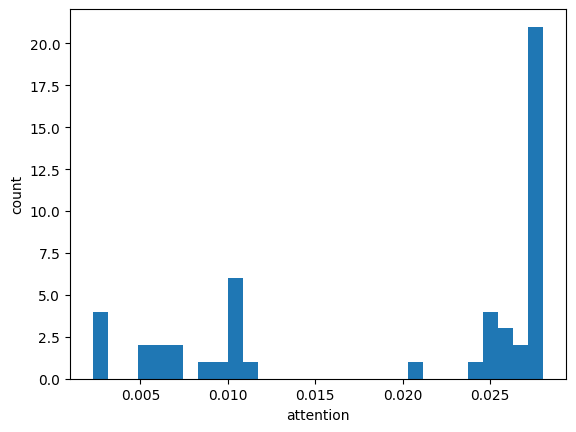

In [12]:
arr = np.asarray(attn)
if arr.ndim > 1:
    arr = arr.ravel()
plt.figure()
plt.hist(arr, bins=30)
plt.xlabel('attention')
plt.ylabel('count')
plt.show()